# EEG Advanced Tutorial: Frequency, Temporal & Connectivity Analysis

This notebook builds on **student_eeg_quickstart.ipynb**. You will learn how to:
- Analyze signals in the **frequency domain** (Power Spectral Density, frequency bands).
- Compare **first vs. last trials** (evoked responses, fatigue/habituation).
- Compare **conditions** (P1 vs. P3) in key channel groups.
- Explore **functional connectivity** via channel correlation matrices.

**Prerequisites:** Complete the basic quickstart and have `utils.py` and your `dataset/` folder in place.

## 0) Setup and interactive backend

We use the same backend as the quickstart so plots remain interactive where possible.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython

import mne
from utils import load_eeg_data, FREQ_BANDS, CHANNEL_GROUPS

# Backend for plots (run once per session). Uses inline so it works on cluster and locally.
ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")
    mne.viz.set_browser_backend("matplotlib")
print("Backend:", mne.viz.get_browser_backend())

# Optional (local only): for scroll, run instead: ip.run_line_magic("matplotlib", "qt") and mne.viz.set_browser_backend("qt"). On cluster use inline.

# Default subject and data path check
SUBJECT_ID = 5
DATA_DIR = Path("dataset")
if not DATA_DIR.exists():
    print("Warning: 'dataset' folder not found. Create it and add .set files.")
else:
    print("Data directory OK:", DATA_DIR.resolve())

Using matplotlib as 2D backend.
Backend: matplotlib
Data directory OK: /storage/ice1/8/1/jlong343/physics-of-cog/dataset


---
## 1) Frequency analysis: Power Spectral Density (PSD)

The **Power Spectral Density (PSD)** tells us how much power the signal has at each frequency. To understand how we get there, we use the **Fourier transform** and then the **Welch method** to estimate the PSD in a stable way.

### Fourier transform (idea)

Any signal in time can be thought of as a sum of **sinusoidal waves** of different frequencies and amplitudes. The **Fourier transform** takes the signal from the **time domain** (amplitude vs. time) and represents it in the **frequency domain** (amplitude or power vs. frequency). So instead of asking "what happened at each moment in time?", we ask "how strong is each frequency component?". For EEG, that is useful because brain rhythms (e.g. alpha ~10 Hz, beta ~20 Hz) are defined by their frequency.

In practice we use the **Discrete Fourier Transform (DFT)**, or its fast implementation the **FFT**, on digitized data. The result for a segment of signal is a **periodogram**: an estimate of how much power is present at each frequency. The **Power Spectral Density** is essentially this power-per-frequency, often normalized so we can compare across recordings.

### Welch method

A single periodogram from one segment of data is very **noisy** (high variance): small changes in the segment can change the estimate a lot. The **Welch method** improves this by:

1. **Splitting** the signal into several shorter, possibly overlapping segments (windows).
2. **Computing** a periodogram for each segment (after applying a window function to reduce edge effects).
3. **Averaging** these periodograms.

Averaging reduces variance, so the PSD estimate is **smoother and more stable**. The trade-off is **frequency resolution**: shorter segments mean we can distinguish fewer fine details in frequency (resolution ≈ 1 / segment length). For EEG, the Welch method is a standard choice because we usually prefer a stable, interpretable spectrum over very high resolution.

---

The classical EEG bands are defined in `utils.FREQ_BANDS`: **Delta** (0.5–4 Hz), **Theta** (4–8 Hz), **Alpha** (8–13 Hz), **Beta** (13–30 Hz), **Gamma** (30–45 Hz). We will overlay these bands on the PSD plot.

In [2]:
def plot_psd_with_bands(epochs, picks="all", ax=None, label=None, color=None, raw=False):
    """Compute PSD and plot with frequency bands shaded (from utils.FREQ_BANDS).

    Optionally plot the raw (time-domain) signal in a second panel so you can
    compare the signal in time with its frequency content.

    Parameters
    ----------
    epochs : mne.Epochs
        Epochs object (e.g. from load_eeg_data). Used to compute PSD and,
        if raw=True, to plot the average time-domain signal.
    picks : str | list
        Channels to include. ``"all"`` or a list of channel names.
        Default ``"all"``.
    ax : matplotlib.axes.Axes | None
        Axes on which to draw the PSD. If ``None``, a new figure/axes is
        created. When ``raw=True``, this axes' figure is reused for the two
        panels (raw + PSD) so only one window is shown.
    label : str | None
        Legend label for the PSD curve. Default ``None``.
    color : str | None
        Color for the PSD curve. Default ``None`` (matplotlib default).
    raw : bool
        If ``True``, show two panels: (1) average raw signal in time,
        (2) PSD with frequency bands. If ``False``, only the PSD is plotted.
        Default ``False``.

    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes on which the PSD was drawn. When ``raw=True``, returns the
        PSD axes (second subplot).
    """
    if raw:
        # Use existing figure if ax was provided, so we don't open a second empty window
        if ax is not None:
            fig = ax.figure
            fig.clf()
            fig.set_size_inches(10, 6)
            ax_raw = fig.add_subplot(2, 1, 1)
            ax_psd = fig.add_subplot(2, 1, 2)
        else:
            fig, (ax_raw, ax_psd) = plt.subplots(2, 1, figsize=(10, 6), sharex=False)
        # Raw: average over epochs and picked channels, plot vs time
        data = epochs.get_data(picks=picks)  # (n_epochs, n_chs, n_times)
        mean_signal = np.mean(data, axis=(0, 1))
        times = epochs.times
        ax_raw.plot(times, mean_signal, color="steelblue", linewidth=0.8)
        ax_raw.set_xlabel("Time (s)")
        ax_raw.set_ylabel("Amplitude (a.u.)")
        ax_raw.set_title("Raw signal (average over trials and channels)")
        ax_raw.grid(True, alpha=0.3)
        ax = ax_psd
    elif ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))

    psd = epochs.compute_psd(method="welch", fmin=0.5, fmax=45, verbose=False)
    psd_data = psd.get_data(picks=picks)
    mean_psd = np.mean(psd_data, axis=(0, 1))
    mean_psd_db = 10 * np.log10(mean_psd + 1e-20)
    freqs = psd.freqs
    ax.plot(freqs, mean_psd_db, label=label, color=color)
    colors_band = {"delta": "#E8E8E8", "theta": "#D4EDDA", "alpha": "#FFF3CD", "beta": "#F8D7DA", "gamma": "#CCE5FF"}
    for band_name, (low, high) in FREQ_BANDS.items():
        ax.axvspan(low, high, alpha=0.8, color=colors_band.get(band_name, "gray"))
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Power (dB)")
    ax.set_xlim(0.5, 45)
    ax.legend(loc="upper right")
    ax.set_title("Power Spectral Density with EEG bands")
    return ax

/storage/ice1/8/1/jlong343/physics-of-cog/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


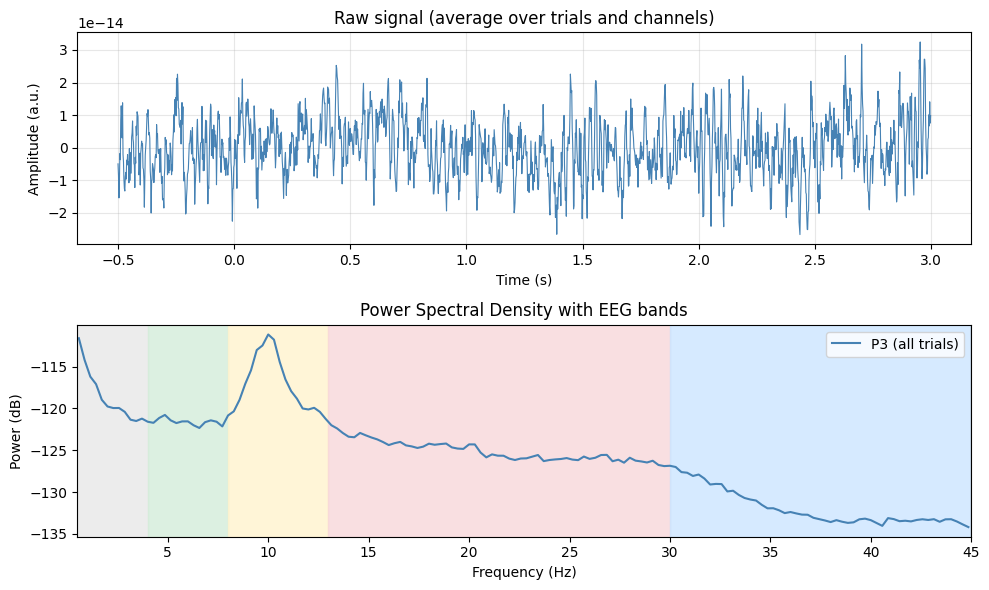

In [3]:
epochs_p3 = load_eeg_data("P3", SUBJECT_ID, channels="all")
fig, ax = plt.subplots(figsize=(10, 4))
plot_psd_with_bands(epochs_p3, label="P3 (all trials)", ax=ax, color="steelblue", raw=True)
plt.tight_layout()
plt.show()

### Repeat with normalized data

The same analysis (raw signal + PSD) can be run on **z-score normalized** data. Load with `normalize=True` so that each channel has mean 0 and standard deviation 1 over all trials and time points. The waveform shape stays the same; comparing the plots helps you see how normalization affects the scale of the raw trace and the power spectrum.

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/storage/ice1/8/1/jlong343/physics-of-cog/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


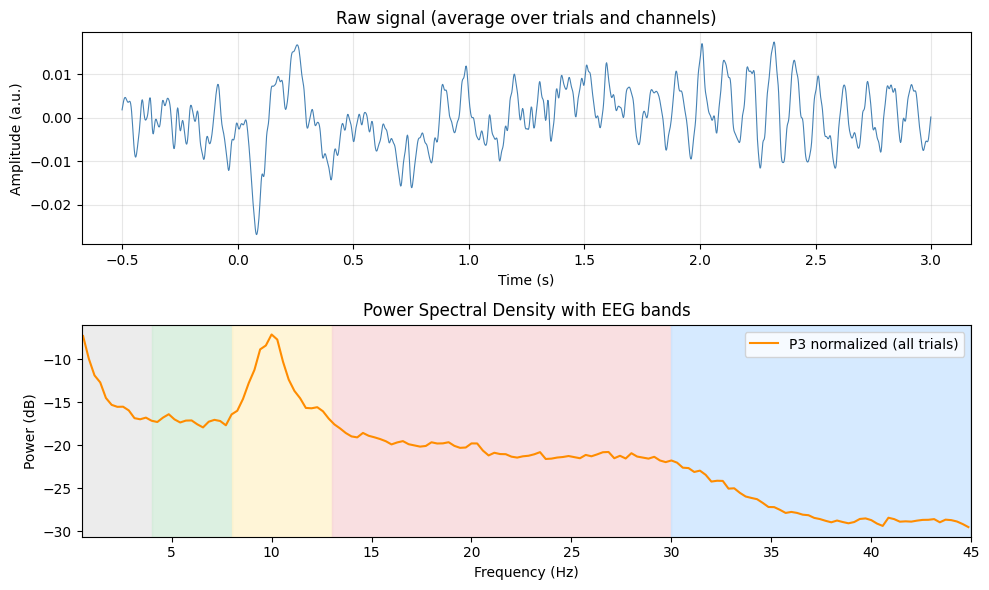

In [4]:
# Same as above, but with z-score normalized data (mean 0, std 1 per channel)
epochs_p3_norm = load_eeg_data("P3", SUBJECT_ID, channels="all", normalize=True)
fig, ax = plt.subplots(figsize=(10, 4))
plot_psd_with_bands(epochs_p3_norm, label="P3 normalized (all trials)", ax=ax, color="darkorange", raw=True)
plt.tight_layout()
plt.show()

### Challenge: Stimulus trial vs baseline (control) trial

We compare the power spectrum of **one trial with a stimulus** (e.g. auditory→tactile) versus **one trial without** (baseline), using **normalized** data. In P3, trial indices with a stimulus vs no stimulus are defined in `utils`; we pick one of each and compare their PSD.

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/storage/ice1/8/1/jlong343/physics-of-cog/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


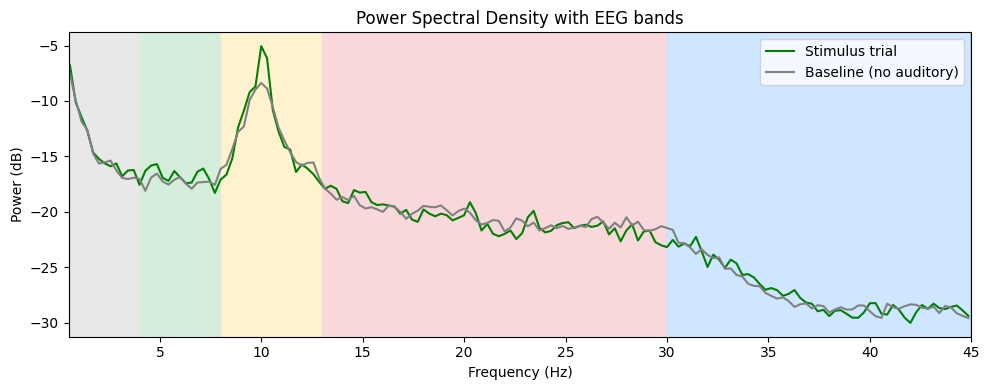

In [5]:
from utils import P3_500ms, P3_missing

epochs_p3 = load_eeg_data("P3", SUBJECT_ID, channels="all", normalize=True)
# Pick one stimulus trial (e.g. audio→tactile 500 ms) and one baseline-like (no auditory)
# P3_500ms and P3_missing are 0-based indices; "no auditory" are the rest.
all_idx = set(range(len(epochs_p3)))
stimulus_idx = list(set(P3_500ms) & all_idx)
baseline_idx = list(all_idx - set(P3_500ms) - set(P3_missing))
if not stimulus_idx:
    stimulus_idx = [0]
if not baseline_idx:
    baseline_idx = [1]

ep_stim = epochs_p3[stimulus_idx[:]]
ep_base = epochs_p3[baseline_idx[:]]

fig, ax = plt.subplots(figsize=(10, 4))
plot_psd_with_bands(ep_stim, label="Stimulus trial", ax=ax, color="green")
plot_psd_with_bands(ep_base, label="Baseline (no auditory)", ax=ax, color="gray")
plt.tight_layout()
plt.show()

**Try different things and see what happens.** Change the condition (e.g. P1 or P2), the subject, the channel group, or the trial indices for stimulus vs baseline. Compare raw vs normalized PSD, or different frequency bands. The best way to learn is to experiment: break things, fix them, and ask yourself what the plots are telling you.

---
## 2) Temporal analysis: First 10 vs last 10 trials (P3)

We compute the **evoked response** (average across trials) for the **first 10** and **last 10** trials. Comparing them can reveal **fatigue**, **habituation**, or **learning** over the session.

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
No projector specified for this dataset. Please consider the method self.add_proj.


/storage/ice1/8/1/jlong343/physics-of-cog/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


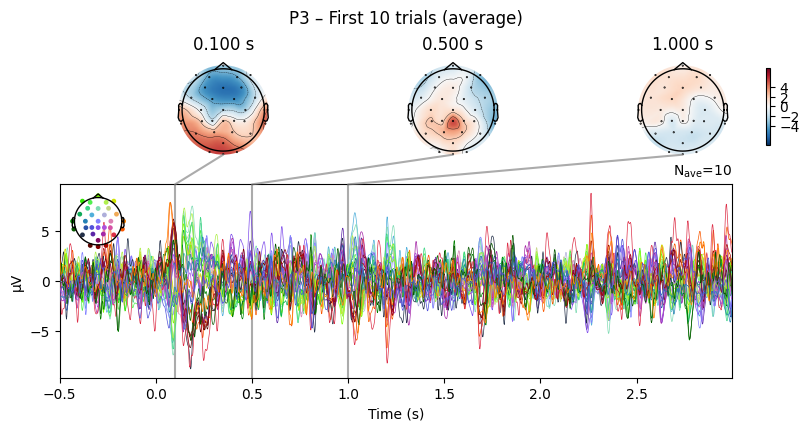

<Figure size 640x480 with 0 Axes>

No projector specified for this dataset. Please consider the method self.add_proj.


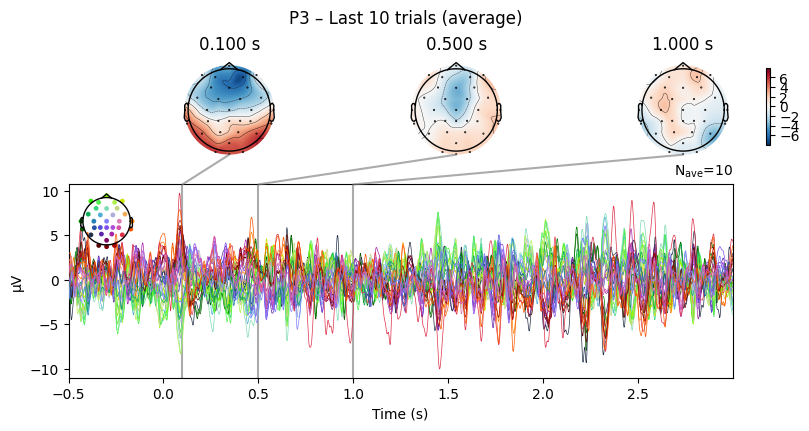

<Figure size 640x480 with 0 Axes>

In [6]:
# Same time points; two figures with butterfly + topomaps, shared colorbar range so comparison is fair.
epochs_p3 = load_eeg_data("P3", SUBJECT_ID, channels="all")
if len(epochs_p3) >= 20:
    evoked_first = epochs_p3[:10].average()
    evoked_last  = epochs_p3[-10:].average()
    d1, d2 = evoked_first.get_data(), evoked_last.get_data()
    lim_v = max(np.abs(d1).max(), np.abs(d2).max())
    lim_uv = lim_v * 8e5  # µV for EEG
    fixed_times = [0.1, 0.5, 1.0]
    topomap_args = dict(vlim=(-lim_uv, lim_uv))

    from matplotlib.colors import Normalize
    from matplotlib import colorbar as cbar
    shared_norm = Normalize(vmin=-lim_uv, vmax=lim_uv)

    def _force_colorbar_scale(fig):
        """Apply shared norm to all topomap mappables and colorbars in this figure."""
        for obj in fig.findobj():
            if isinstance(obj, cbar.Colorbar):
                obj.norm = shared_norm
                if hasattr(obj, "mappable") and obj.mappable is not None:
                    obj.mappable.set_norm(shared_norm)
                if hasattr(obj, "update_normal"):
                    obj.update_normal(obj.mappable)
            elif hasattr(obj, "set_norm"):
                try:
                    obj.set_norm(shared_norm)
                except Exception:
                    pass
            elif hasattr(obj, "set_clim"):
                try:
                    obj.set_clim(-lim_uv, lim_uv)
                except Exception:
                    pass

    evoked_first.plot_joint(title="P3 – First 10 trials (average)", times=fixed_times, topomap_args=topomap_args)
    _force_colorbar_scale(plt.gcf())
    plt.show()
    evoked_last.plot_joint(title="P3 – Last 10 trials (average)", times=fixed_times, topomap_args=topomap_args)
    _force_colorbar_scale(plt.gcf())
    plt.show()

### What to look for

- **Habituation:** Reduced amplitude in later trials (e.g. smaller P3) as the participant gets used to the stimulus.
- **Fatigue:** Slower or noisier responses toward the end of the block.
- **Learning:** Sometimes *increased* or more consistent responses in the last block if the task involves learning.

Interpreting these effects requires knowing the task and condition; use these plots as a starting point for discussion.

---
## 3) Condition comparison: P1 vs P3

**P1** involves a tactile stimulus at 500 ms; **P3** involves a *missing* tactile stimulus (expectation violation). We load the same subject for both conditions and compare activity in predefined channel groups (**MI** = Multisensory Integration, **SU** = Stimulus Uncertainty) from `utils.CHANNEL_GROUPS`.

In [7]:
epochs_p1 = load_eeg_data("P1", SUBJECT_ID, channels="all")
epochs_p3 = load_eeg_data("P3", SUBJECT_ID, channels="all")
ev_p1 = epochs_p1.average()
ev_p3 = epochs_p3.average()
print("P1 channels:", ev_p1.ch_names[:5], "...")
print("P3 channels:", ev_p3.ch_names[:5], "...")

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/storage/ice1/8/1/jlong343/physics-of-cog/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
P1 channels: ['AF7', 'FPZ', 'AF8', 'AF3', 'AF4'] ...
P3 channels: ['AF7', 'FPZ', 'AF8', 'AF3', 'AF4'] ...


/storage/ice1/8/1/jlong343/physics-of-cog/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


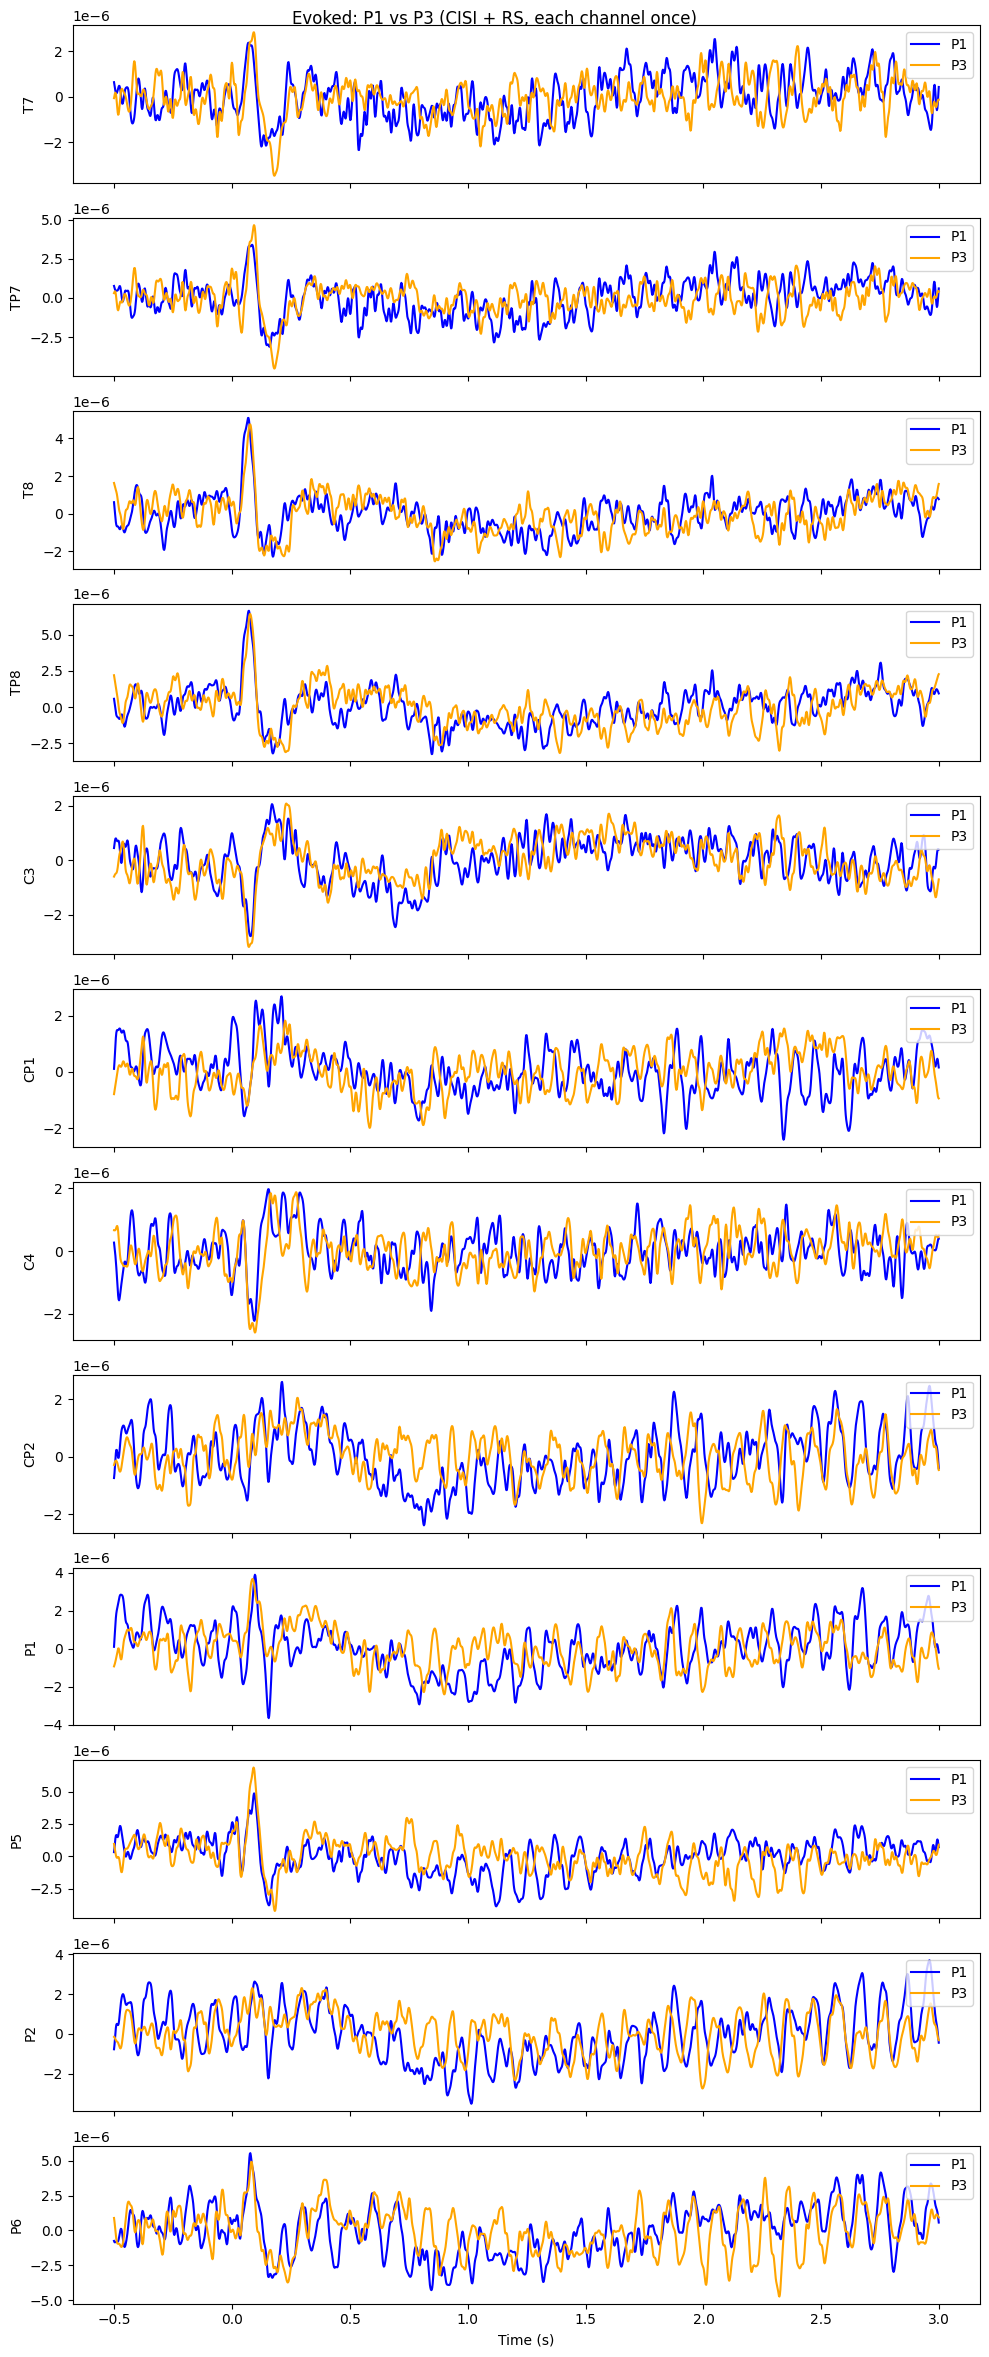

In [8]:
# Union of channels from CISI and RS (no duplicates), only those in both P1 and P3
picks = []
seen = set()
for group_name in ["CISI", "RS"]:
    if group_name not in CHANNEL_GROUPS:
        continue
    for ch in CHANNEL_GROUPS[group_name]:
        if ch not in seen and ch in ev_p1.ch_names and ch in ev_p3.ch_names:
            seen.add(ch)
            picks.append(ch)
if not picks:
    print("No common channels in CISI/RS for P1 and P3.")
else:
    fig, axes = plt.subplots(len(picks), 1, figsize=(10, 2 * len(picks)), sharex=True)
    if len(picks) == 1:
        axes = [axes]
    for ax, ch in zip(axes, picks):
        ax.plot(ev_p1.times, ev_p1.get_data(picks=[ch])[0], label="P1", color="blue")
        ax.plot(ev_p3.times, ev_p3.get_data(picks=[ch])[0], label="P3", color="orange")
        ax.set_ylabel(ch)
        ax.legend(loc="upper right")
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle("Evoked: P1 vs P3 (CISI + RS, each channel once)")
    plt.tight_layout()
    plt.show()

---
## 4) Spatial connectivity: Correlation matrix

We compute the **Pearson correlation** between all channel time series (averaged over trials or per trial block). A **heatmap** shows which channels tend to co-vary—a simple view of "which regions are working together."

In [9]:
def correlation_heatmap(epochs, title="Channel correlation", ax=None):
    """Compute Pearson correlation across channels (averaged over time and trials) and plot heatmap."""
    data = epochs.get_data()  # (n_epochs, n_chs, n_times)
    # Flatten time: (n_epochs * n_times, n_chs)
    n_ep, n_ch, n_t = data.shape
    data_flat = data.transpose(0, 2, 1).reshape(-1, n_ch)
    corr = np.corrcoef(data_flat.T)
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(n_ch))
    ax.set_yticks(range(n_ch))
    ax.set_xticklabels(epochs.ch_names, rotation=90, ha="right")
    ax.set_yticklabels(epochs.ch_names)
    plt.colorbar(im, ax=ax, label="Pearson r")
    ax.set_title(title)
    return ax

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/storage/ice1/8/1/jlong343/physics-of-cog/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


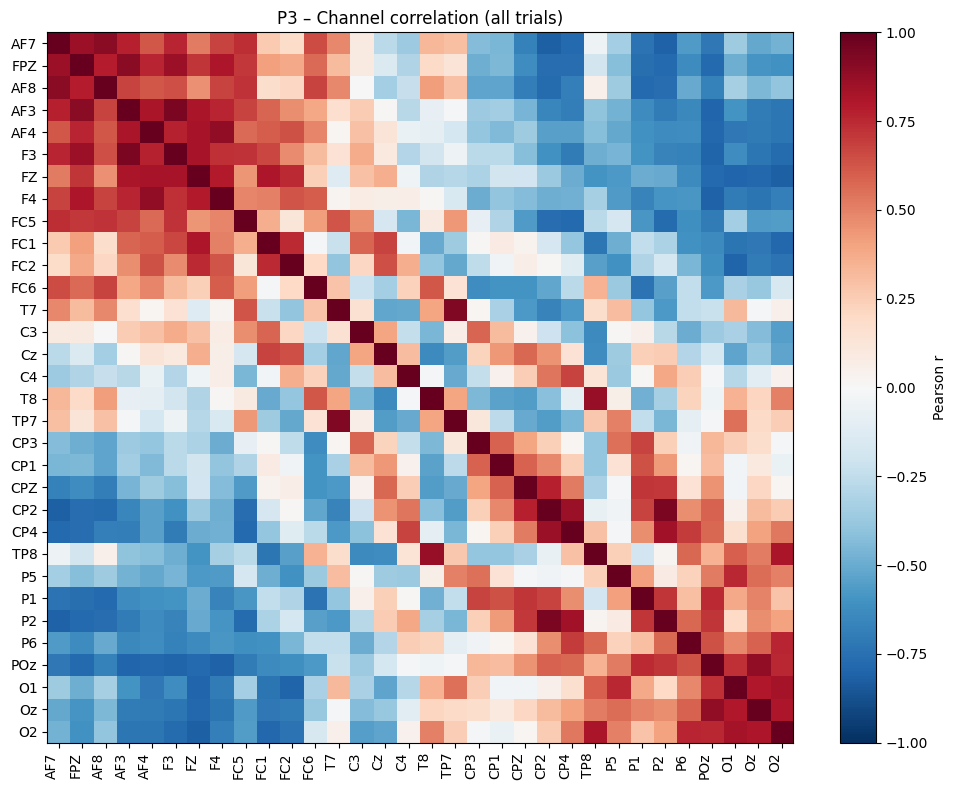

In [10]:
epochs_p3 = load_eeg_data("P3", SUBJECT_ID, channels="all")
fig, ax = plt.subplots(figsize=(10, 8))
correlation_heatmap(epochs_p3, title="P3 – Channel correlation (all trials)", ax=ax)
plt.tight_layout()
plt.show()

### Compare correlation: Beginning vs end of session (all conditions)

For each condition we split trials into **first 10** and **last 10**, compute a correlation matrix for each, and the **difference** (last 10 − first 10). One figure: 5 conditions × 3 panels (First 10, Last 10, Difference) = 15 heatmaps. Differences suggest how coupling changes over the session per condition.

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/storage/ice1/8/1/jlong343/physics-of-cog/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/storage/ice1/8/1/jlong343/physics-of-cog/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/storage/ice1/8/1/jlong343/physics-of-cog/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)
/storage/ice1/8/1/jlong343/physics-of-cog/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


/storage/ice1/8/1/jlong343/physics-of-cog/utils.py:127: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  epochs = mne.io.read_epochs_eeglab(file_path, verbose=False)


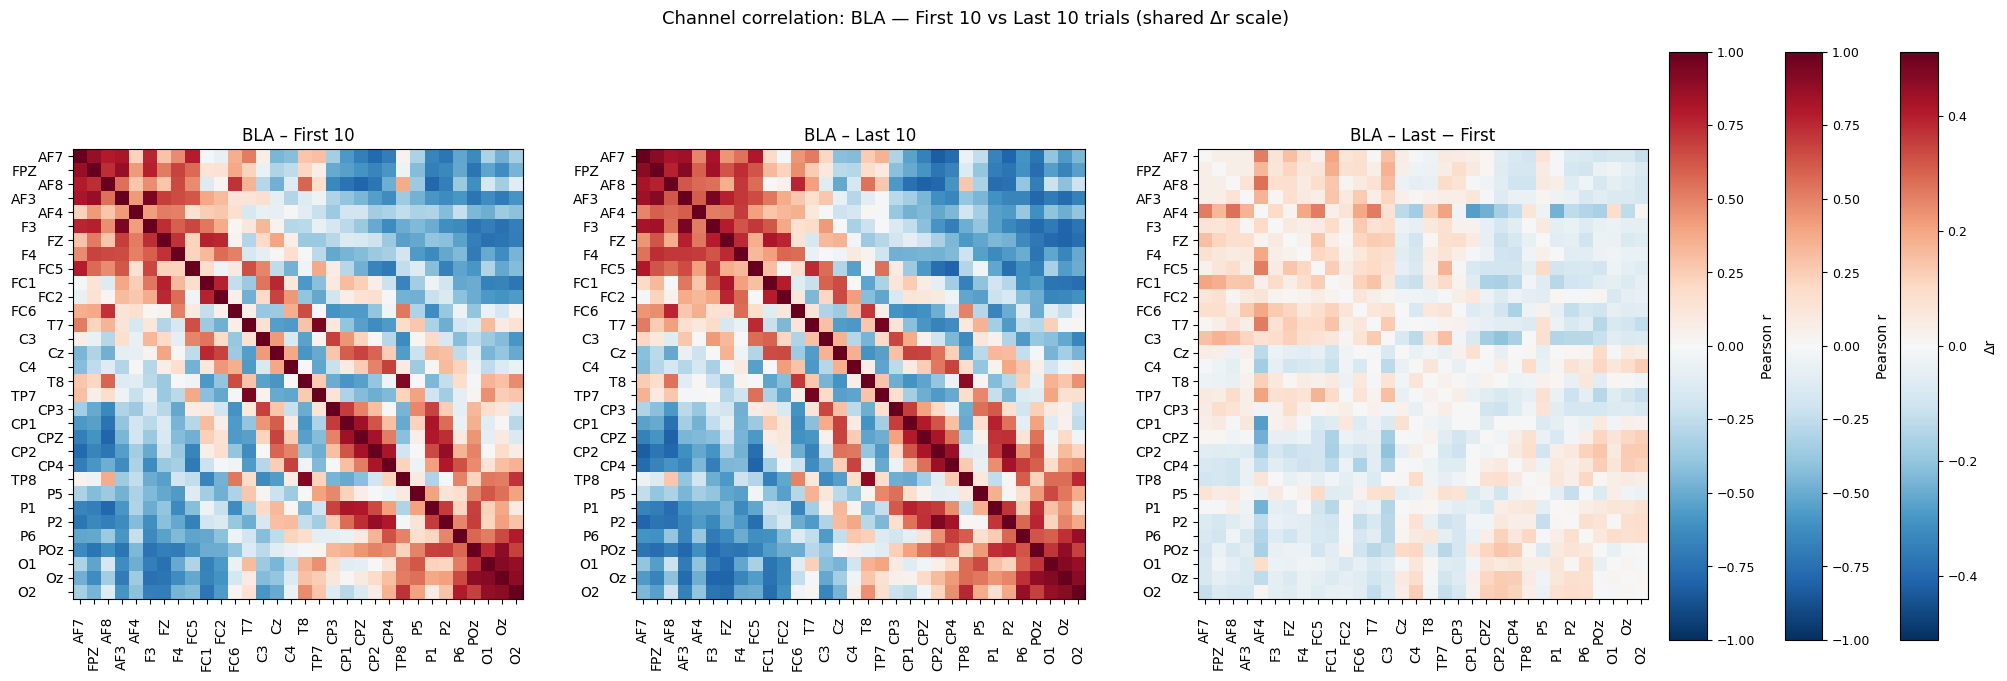

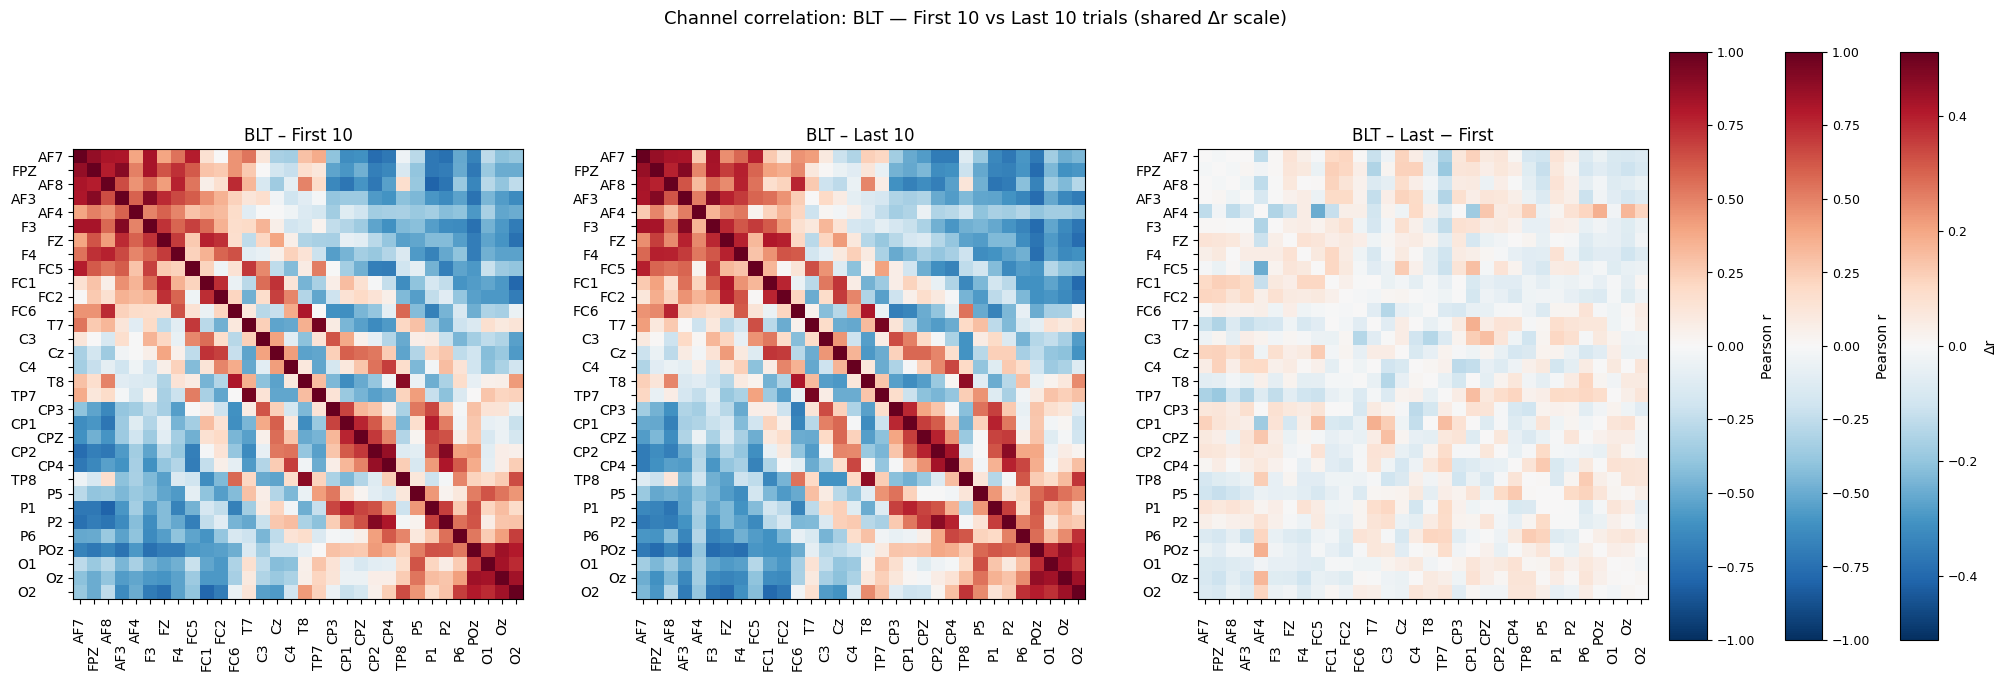

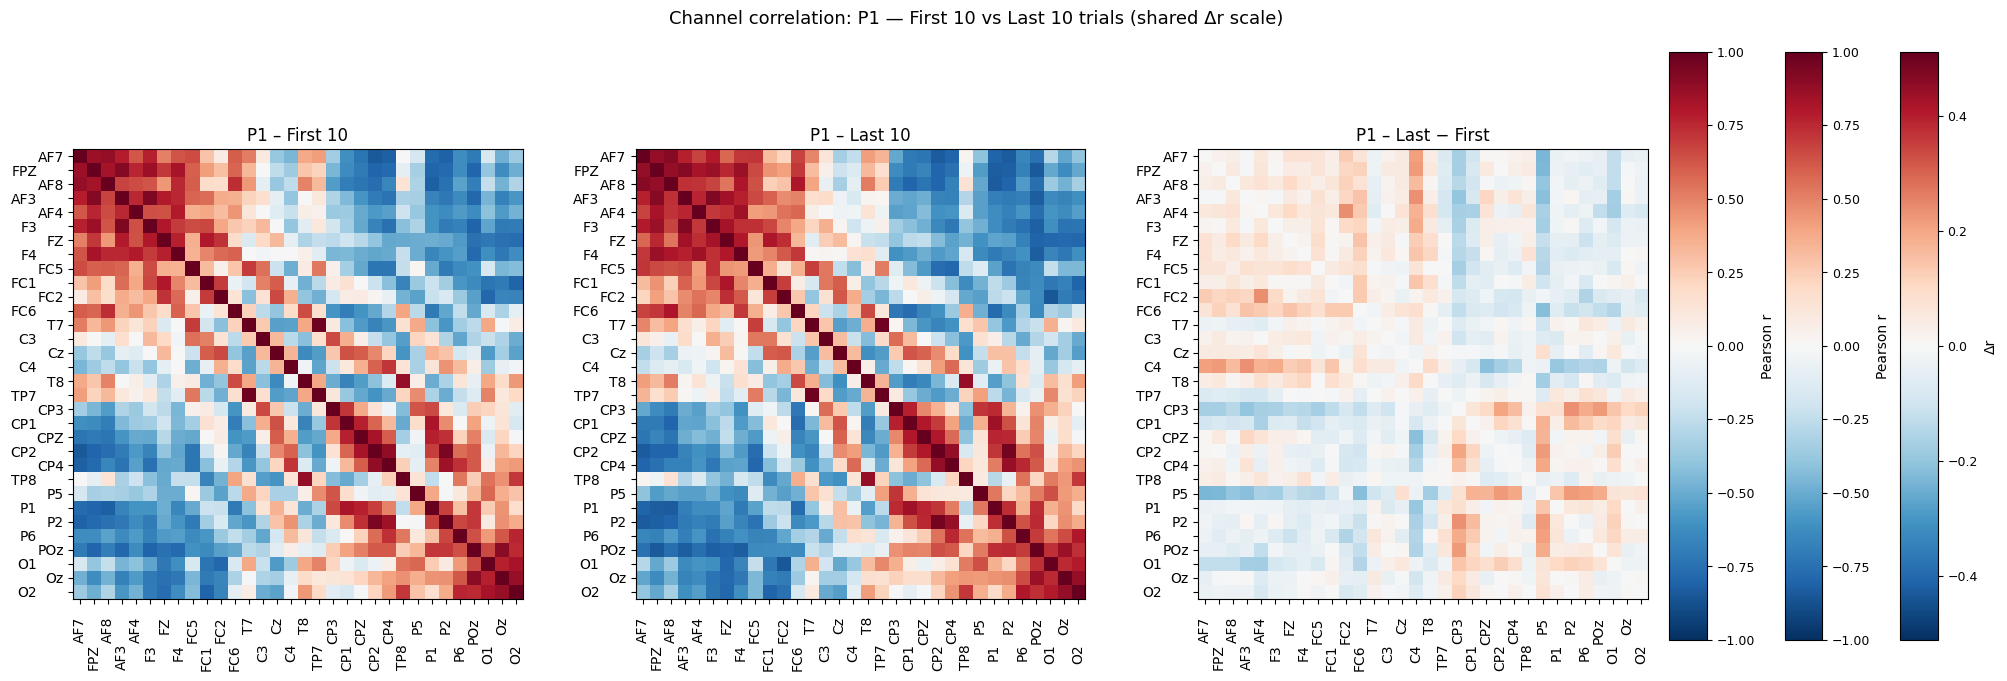

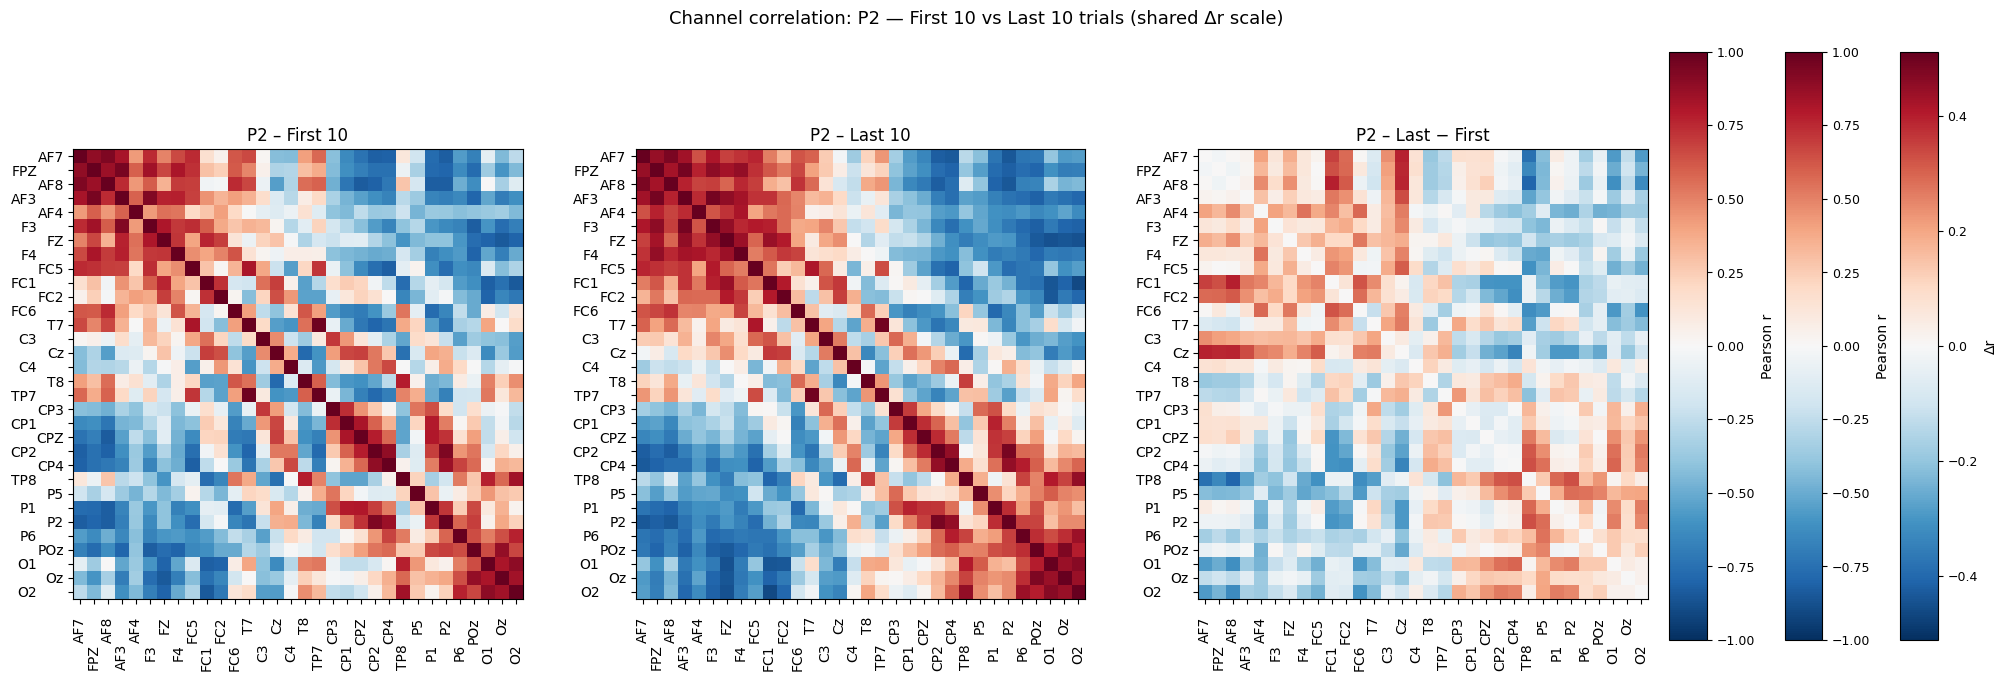

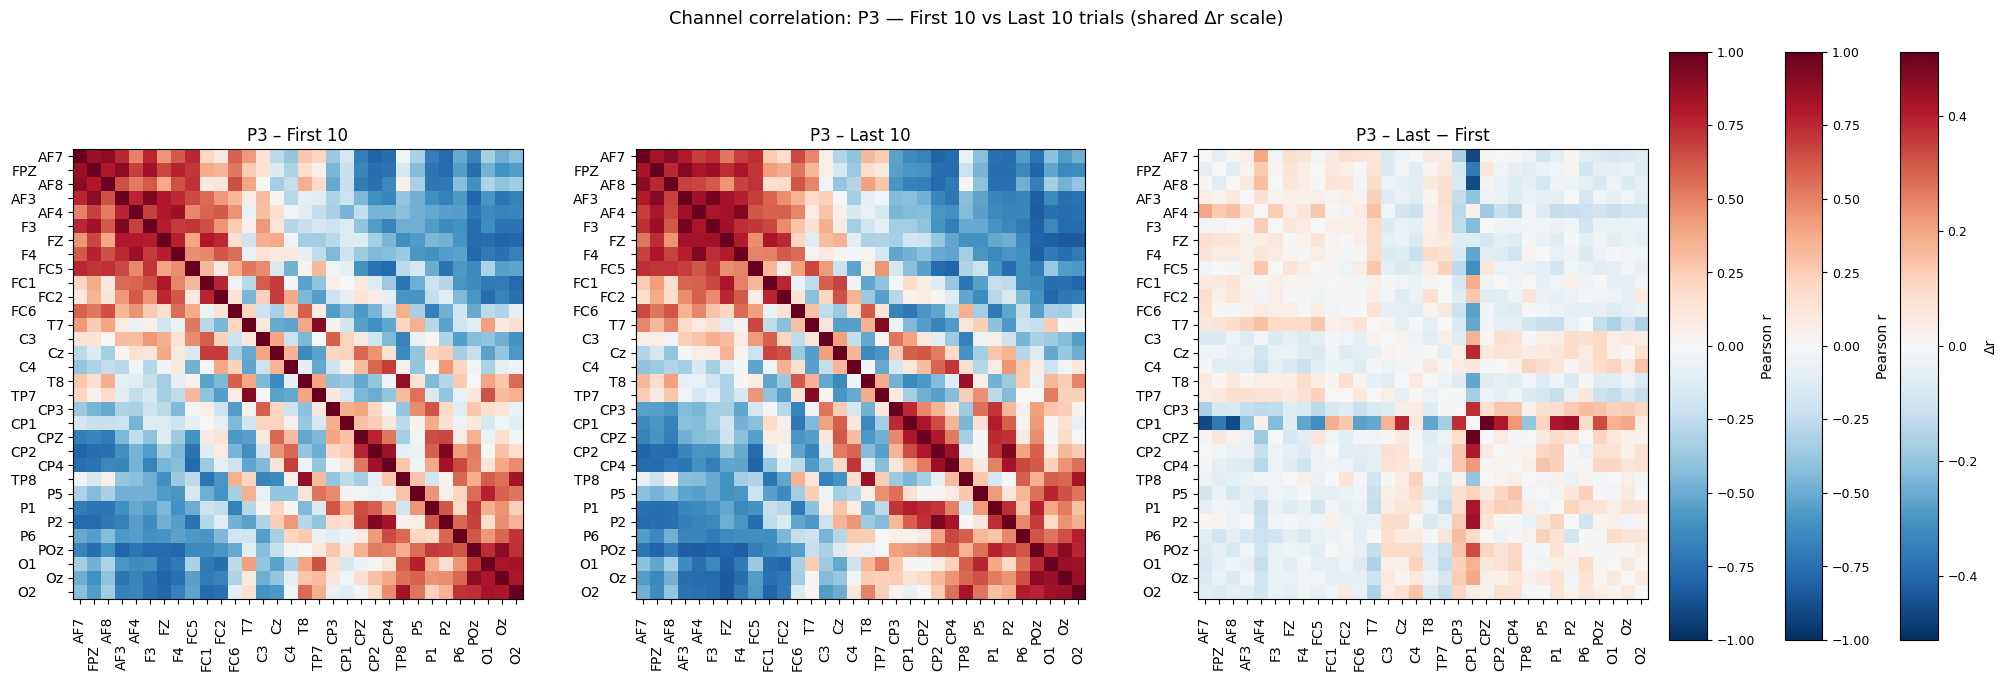

In [11]:
def _corr_matrix(epochs):
    """Return Pearson correlation matrix (n_ch, n_ch) from epochs."""
    data = epochs.get_data()
    n_ep, n_ch, n_t = data.shape
    data_flat = data.transpose(0, 2, 1).reshape(-1, n_ch)
    return np.corrcoef(data_flat.T)

conditions = ["BLA", "BLT", "P1", "P2", "P3"]
n_cond = len(conditions)
mid = 10
# First pass: load data and compute all diff matrices to get a shared scale for the difference column
results = []
diff_max = 0.0
for cond in conditions:
    try:
        epochs = load_eeg_data(cond, SUBJECT_ID, channels="all")
    except FileNotFoundError:
        results.append((cond, None, None, None, None))
        continue
    n = len(epochs)
    if n < 2 * mid:
        results.append((cond, None, None, None, None))
        continue
    first_10 = epochs[:mid]
    last_10 = epochs[-mid:]
    corr_first = _corr_matrix(first_10)
    corr_last = _corr_matrix(last_10)
    diff = corr_last - corr_first
    diff_max = max(diff_max, np.abs(diff).max())
    results.append((cond, epochs.ch_names, corr_first, corr_last, diff))
diff_lim = max(diff_max, 1e-6)

# One figure per condition (5 separate plots), each with 3 panels: First 10, Last 10, Last − First
panel_inches = 7
for i, item in enumerate(results):
    cond, ch_names, corr_first, corr_last, diff = item
    if ch_names is None:
        fig, ax = plt.subplots(figsize=(5, 2))
        ax.text(0.5, 0.5, f"{cond} — file not found or too few trials", ha="center", va="center", fontsize=12)
        ax.axis("off")
        plt.tight_layout()
        plt.show()
        continue
    fig, axes = plt.subplots(1, 3, figsize=(3 * panel_inches, panel_inches))
    n_ch = len(ch_names)
    # Ticks at cell centers so each label clearly corresponds to one column/row
    xticks = np.arange(n_ch) + 0.5
    yticks = np.arange(n_ch) + 0.5
    xticklabels = ch_names
    yticklabels = ch_names
    im_col = []
    for j, (mat, title, vmin, vmax) in enumerate([
        (corr_first, "First 10", -1, 1),
        (corr_last, "Last 10", -1, 1),
        (diff, "Last − First", -diff_lim, diff_lim),
    ]):
        ax = axes[j]
        # extent so each cell is [0,1], [1,2], ... and ticks at 0.5, 1.5, ... fall in the center
        im = ax.imshow(
            mat, cmap="RdBu_r", vmin=vmin, vmax=vmax, aspect="equal",
            extent=[0, n_ch, n_ch, 0], origin="upper", interpolation="nearest"
        )
        im_col.append(im)
        ax.set_xlim(0, n_ch)
        ax.set_ylim(n_ch, 0)
        ax.set_xticks(xticks)
        ax.set_yticks(yticks)
        ax.set_xticklabels(xticklabels, rotation=90, ha="center", fontsize=10)
        ax.set_yticklabels(yticklabels, fontsize=10)
        ax.set_title(f"{cond} – {title}", fontsize=12)
        for ii, lbl in enumerate(ax.get_xticklabels()):
            pos = list(lbl.get_position())
            offset = 0.04 if ii % 2 == 0 else 0.10
            lbl.set_position((pos[0], pos[1] - offset))
            lbl.set_transform(ax.get_xaxis_transform())
        for ii, lbl in enumerate(ax.get_yticklabels()):
            pos = list(lbl.get_position())
            offset = 0.02 if ii % 2 == 0 else 0.08
            lbl.set_position((pos[0] - offset, pos[1]))
            lbl.set_transform(ax.get_yaxis_transform())
    fig.subplots_adjust(left=0.07, right=0.82, top=0.88, bottom=0.04, wspace=0.25)
    for j in range(3):
        cax = fig.add_axes([0.83 + j * 0.055, 0.08, 0.018, 0.84])
        cb = fig.colorbar(im_col[j], cax=cax, label="Pearson r" if j < 2 else "Δr")
        cb.ax.tick_params(labelsize=9)
    fig.suptitle(f"Channel correlation: {cond} — First 10 vs Last 10 trials (shared Δr scale)", fontsize=13, y=0.98)
    plt.show()

---
## Summary

- **Frequency:** PSD and frequency bands help characterize oscillatory activity; comparing stimulus vs baseline trials can reveal condition-related power changes.
- **Temporal:** First vs last trial averages (evoked) can indicate habituation, fatigue, or learning.
- **Conditions:** P1 vs P3 evoked responses in MI/SU channel groups show condition-specific patterns.
- **Connectivity:** Correlation matrices give a simple view of channel co-activation; comparing first vs second half shows how coupling may change over the session.